<a href="https://colab.research.google.com/github/viktoruebelhart/studies/blob/main/Hands_on_Practice_Lab_Data_Wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this lab, you will use the skills acquired in the module and address the issues of handling missing data, correct the data type of the dataframe attribute and execute the processes of data standardization and data normalization on specific attributes of the dataset.

Objectives
After completing this lab you will be able to:

Handle missing data in different ways

Correct the data type of different data values as per requirement

Standardize and normalize the appropriate data attributes

Visualize the data as grouped bar graph using Binning

Cnverting a categorical data into numerical indicator variables


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

In [4]:
df = pd.read_csv(file_path, header=0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 24.3+ KB


In [5]:
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
Manufacturer,0
Category,0
Screen,0
GPU,0
OS,0
CPU_core,0
Screen_Size_cm,4
CPU_frequency,0
RAM_GB,0


In [8]:
if (df == '?').any().any():
    print("There are '?' characters in the DataFrame.")
else:
    print("There are no '?' characters in the DataFrame.")

There are no '?' characters in the DataFrame.


Note that we can update the `Screen_Size_cm` column such that all values are rounded to nearest 2 decimal places by using `numpy.round()`


In [11]:
df[['Screen_Size_cm']] = np.round(df[['Screen_Size_cm']],2)
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


In [12]:
missing_data = df.isnull()
print(missing_data.head())
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

   Unnamed: 0  Manufacturer  Category  Screen    GPU     OS  CPU_core  \
0       False         False     False   False  False  False     False   
1       False         False     False   False  False  False     False   
2       False         False     False   False  False  False     False   
3       False         False     False   False  False  False     False   
4       False         False     False   False  False  False     False   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0           False          False   False           False      False  False  
1           False          False   False           False      False  False  
2           False          False   False           False      False  False  
3           False          False   False           False      False  False  
4           False          False   False           False      False  False  
Unnamed: 0
Unnamed: 0
False    238
Name: count, dtype: int64

Manufacturer
Manufacturer
False    23

Replace with mean Weight_kg

In [16]:
avg_weight = df["Weight_kg"].mean(axis=0)
avg_weight = np.round(avg_weight,2)
print("Average of Weight_kg:", avg_weight)

Average of Weight_kg: 1.86


In [17]:
df['Weight_kg'].replace(np.nan, avg_weight, inplace=True)

/tmp/ipython-input-3952734942.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight_kg'].replace(np.nan, avg_weight, inplace=True)


In [20]:
df['Weight_kg'].isnull().sum()

np.int64(0)

Replace with the most frequent value
Missing values in attributes that have categorical data are best replaced using the most frequent value. We note that values in "Screen_Size_cm" attribute are categorical in nature, and some values are missing. Therefore, write a code to replace the missing values of Screen Size with the most frequent value of the attribute.

In [28]:
df['Screen_Size_cm'].value_counts().idxmax()

39.62

In [25]:
df["Screen_Size_cm"].replace(np.nan, "39.62", inplace=True)

/tmp/ipython-input-1962045599.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Screen_Size_cm"].replace(np.nan, "39.62", inplace=True)


In [26]:
df.isnull().sum()

,0
Unnamed: 0,0
Manufacturer,0
Category,0
Screen,0
GPU,0
OS,0
CPU_core,0
Screen_Size_cm,0
CPU_frequency,0
RAM_GB,0


Fixing the data types
Both "Weight_kg" and "Screen_Size_cm" are seen to have the data type "Object", while both of them should be having a data type of "float"

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  238 non-null    object 
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       238 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 24.3+ KB


In [30]:
df[["Weight_kg", "Screen_Size_cm"]] = df[["Weight_kg", "Screen_Size_cm"]].astype("float")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  238 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       238 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 24.3+ KB


Data Standardization
The value of Screen_size usually has a standard unit of inches. Similarly, weight of the laptop is needed to be in pounds. Use the below mentioned units of conversion and write a code to modify the columns of the dataframe accordingly. Update their names as well.

1 inch = 2.54 cm

1 kg   = 2.205 pounds

In [31]:
df['Screen_Size_inch'] = df['Screen_Size_cm'] / 2.54
df['Weight_pounds'] = df["Weight_kg"] * 2.205
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_inch,Weight_pounds
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978,14.000000,3.52800
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634,15.598425,4.85100
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946,15.598425,4.85100
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244,13.299213,2.69010
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837,15.598425,4.21155


Data Normalization

Often it is required to normalize a continuous data attribute. Write a code to normalize the "CPU_frequency" attribute with respect to the maximum value available in the dataset.

In [32]:
df['CPU_frequency'].describe()

,CPU_frequency
count,238.000000
mean,2.360084
std,0.411393
min,1.200000
25%,2.000000
50%,2.500000
75%,2.700000
max,2.900000


In [33]:
# replace (original value) by (original value)/(maximum value)
df['CPU_frequency'] = df['CPU_frequency']/df['CPU_frequency'].max()

In [35]:
df['CPU_frequency'].describe()

,CPU_frequency
count,238.000000
mean,0.813822
std,0.141860
min,0.413793
25%,0.689655
50%,0.862069
75%,0.931034
max,1.000000


Binning

Binning is a process of creating a categorical attribute which splits the values of a continuous data into a specified number of groups. In this case, write a code to create 3 bins for the attribute "Price". These bins would be named "Low", "Medium" and "High". The new attribute will be named "Price-binned".

In [38]:
df['Price'].describe()

,Price
count,238.000000
mean,1462.344538
std,574.607699
min,527.000000
25%,1066.500000
50%,1333.000000
75%,1777.000000
max,3810.000000


In [36]:
group_names = ['Low', 'Medium', 'High']

In [37]:
bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)
bins

array([ 527.        , 1621.33333333, 2715.66666667, 3810.        ])

In [40]:
df['Price-binned'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True )
df[['Price','Price-binned']].head(20)

,Price,Price-binned
0,978,Low
1,634,Low
2,946,Low
3,1244,Low
4,837,Low
5,1016,Low
6,1117,Low
7,866,Low
8,812,Low
9,1068,Low


In [42]:
df['Price-binned'].value_counts()

,count
Price-binned,
Low,160
Medium,72
High,6


Text(0.5, 1.0, 'Price bins')

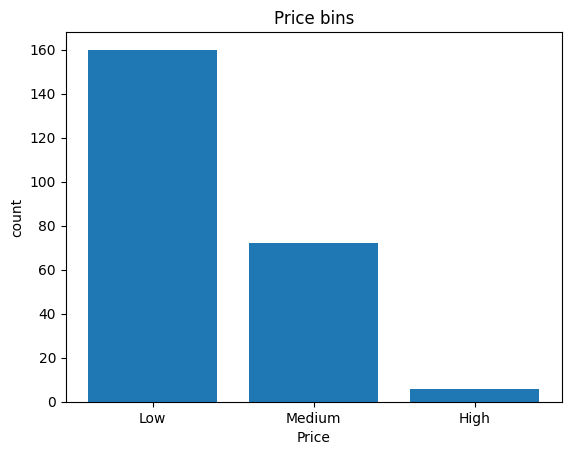

In [43]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
pyplot.bar(group_names, df["Price-binned"].value_counts())

# set x/y labels and plot title
plt.pyplot.xlabel("Price")
plt.pyplot.ylabel("count")
plt.pyplot.title("Price bins")

Indicator variables

Convert the "Screen" attribute of the dataset into 2 indicator variables, "Screen-IPS_panel" and "Screen-Full_HD". Then drop the "Screen" attribute from the dataset.

In [45]:
df['Screen'].unique()

array(['IPS Panel', 'Full HD'], dtype=object)

In [46]:
dummy_variable_1 = pd.get_dummies(df["Screen"])
dummy_variable_1.head()

,Full HD,IPS Panel
0,False,True
1,True,False
2,True,False
3,False,True
4,True,False


In [48]:
dummy_variable_1.rename(columns={'Full HD':'Screen Full HD', 'IPS Panel':'Screen IPS Panel'}, inplace=True)
dummy_variable_1.head()

,Screen Full HD,Screen IPS Panel
0,False,True
1,True,False
2,True,False
3,False,True
4,True,False


In [49]:
# merge data frame "df" and "dummy_variable_1"
df = pd.concat([df, dummy_variable_1], axis=1)
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_inch,Weight_pounds,Price-binned,Screen Full HD,Screen IPS Panel
0,0,Acer,4,IPS Panel,2,1,5,35.56,0.551724,8,256,1.60,978,14.000000,3.52800,Low,False,True
1,1,Dell,3,Full HD,1,1,3,39.62,0.689655,4,256,2.20,634,15.598425,4.85100,Low,True,False
2,2,Dell,3,Full HD,1,1,7,39.62,0.931034,8,256,2.20,946,15.598425,4.85100,Low,True,False
3,3,Dell,4,IPS Panel,2,1,5,33.78,0.551724,8,128,1.22,1244,13.299213,2.69010,Low,False,True
4,4,HP,4,Full HD,2,1,7,39.62,0.620690,8,256,1.91,837,15.598425,4.21155,Low,True,False


In [51]:
# drop original column "Screen" from "df"
df.drop("Screen", axis = 1, inplace=True)

KeyError: "['Screen'] not found in axis"

In [52]:
df.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_inch,Weight_pounds,Price-binned,Screen Full HD,Screen IPS Panel
0,0,Acer,4,2,1,5,35.56,0.551724,8,256,1.60,978,14.000000,3.52800,Low,False,True
1,1,Dell,3,1,1,3,39.62,0.689655,4,256,2.20,634,15.598425,4.85100,Low,True,False
2,2,Dell,3,1,1,7,39.62,0.931034,8,256,2.20,946,15.598425,4.85100,Low,True,False
3,3,Dell,4,2,1,5,33.78,0.551724,8,128,1.22,1244,13.299213,2.69010,Low,False,True
4,4,HP,4,2,1,7,39.62,0.620690,8,256,1.91,837,15.598425,4.21155,Low,True,False


In [53]:
df.to_csv('clean_df.csv')